In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

from alphapackage.operators import *
from alphapackage.data_utils import DataHolder
from alphapackage.core import BaseAlpha, AlphaStats

from alphas import Alpha1, Alpha2, Alpha3, Alpha4, Alpha5, Alpha6, Alpha7, Alpha8, Alpha9
# from alphas import BasePortfolio
from alphas import PortfolioEqual, PortfolioSharpe, PortfolioPNL, PortfolioCorr

import warnings
warnings.filterwarnings("ignore")

In [2]:
dh = DataHolder(path="../csv_data", filter_outliers=False)
dh.data['return'].head()

,A,AACG,AAMI,AAOI,AAPL,AAT,ABBV,ABCB,ABEV,ABG,...,YDKG,YELP,YPF,ZBRA,ZEUS,ZG,ZTR,ZTS,ZUMZ,ZWS
Date,,,,,,,,,,,,,,,,,,,,,
2016-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-01-05,-0.003441,0.025118,0.008801,-0.012891,-0.025059,0.031117,-0.004166,0.003994,0.014051,-0.020896,...,-0.001795,-0.035507,-0.004430,-0.025117,-0.005968,-0.019176,0.000826,0.015655,0.009894,-0.032751
2016-01-06,0.004439,0.101072,-0.035571,-0.001866,-0.019570,-0.001032,0.000174,-0.016524,-0.011547,-0.119607,...,0.003597,-0.026672,-0.047680,-0.039957,0.000000,-0.006656,-0.009076,0.000208,-0.015023,-0.040632
2016-01-07,-0.042475,-0.116829,-0.053583,-0.047352,-0.042204,-0.021430,-0.002963,-0.018668,-0.039719,-0.029997,...,-0.010753,-0.024701,-0.016021,-0.045316,-0.057461,-0.036013,-0.011657,-0.030404,0.114721,-0.047059
2016-01-08,-0.010513,-0.070866,0.004411,-0.032701,0.005288,-0.008971,-0.027268,-0.009829,0.017031,-0.040992,...,0.000000,-0.008706,-0.006106,-0.002693,-0.032757,0.037793,-0.002527,-0.014605,-0.011303,-0.031481


## Alpha correlations

In [3]:
pnls = {}

def run_alpha(Alpha : BaseAlpha):
    global rtrns, stats

    test_alpha = Alpha()
    test_alpha.get_weights(dh)
    test_alpha.run_weights(dh)

    pnls[Alpha.__name__] = test_alpha.pnl

In [4]:
run_alpha(Alpha1)
run_alpha(Alpha2)
run_alpha(Alpha3)
run_alpha(Alpha4)
run_alpha(Alpha5)
run_alpha(Alpha6)
run_alpha(Alpha7)
run_alpha(Alpha8)
run_alpha(Alpha9)

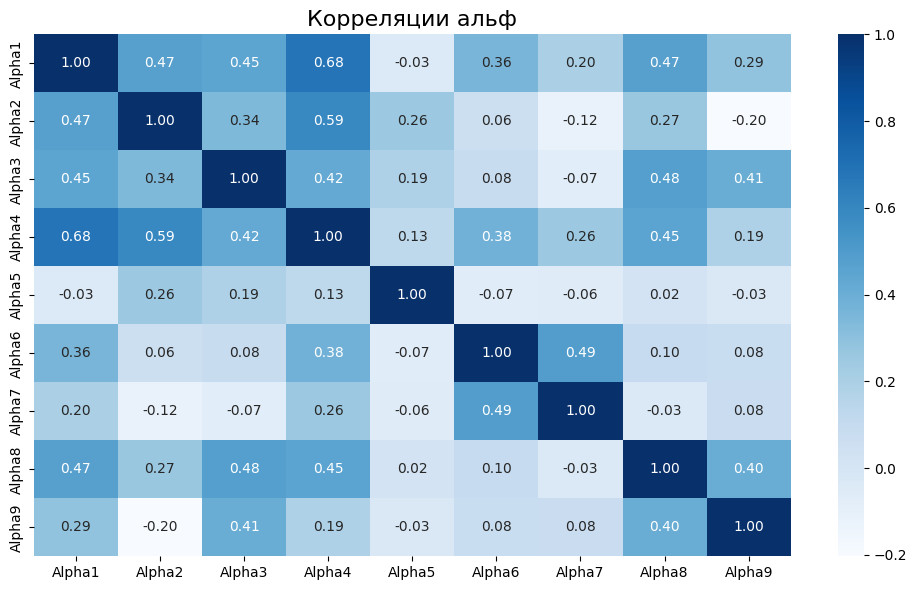

In [5]:
df = pd.DataFrame(pnls)
correlation_matrix = df.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(
    correlation_matrix,
    cmap='Blues',
    annot=True,
    fmt='.2f'
)
plt.title('Корреляции альф', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
R = np.array([pnl.mean() for pnl in pnls.values()])

In [ ]:
import cvxpy as cp

In [ ]:
x = cp.Variable(9)

C = correlation_matrix.to_numpy()
objective = cp.Minimize(cp.quad_form(x, C))

constraints = [
    R.T @ x == 1
]
problem = cp.Problem(objective, constraints)

result = problem.solve()
print(x.value)

[421.05276949 376.27479484 -44.92791558 -44.21463077 130.00673688
 186.15573878  48.35852091  11.53932339  71.05083202]


In [59]:
df = pd.DataFrame(np.array(x.value))

df.div(df.abs().sum())

,0
0,0.315731
1,0.282154
2,-0.033690
3,-0.033155
4,0.097487
5,0.139591
6,0.036262
7,0.008653
8,0.053278


In [55]:
normalize((pd.DataFrame(np.array(x.value))))

,0
0,1.0
1,1.0
2,-1.0
3,-1.0
4,1.0
5,1.0
6,1.0
7,1.0
8,1.0


In [6]:
del pnls

## Heuristic portfolios

In [3]:
alpha1 = Alpha1()
alpha1.get_weights(dh)
alpha1.run_weights(dh)

alpha2 = Alpha2()
alpha2.get_weights(dh)
alpha2.run_weights(dh)

alpha3 = Alpha3()
alpha3.get_weights(dh)
alpha3.run_weights(dh)

alpha5 = Alpha5()
alpha5.get_weights(dh)
alpha5.run_weights(dh)

alpha6 = Alpha6()
alpha6.get_weights(dh)
alpha6.run_weights(dh)

alpha7 = Alpha7()
alpha7.get_weights(dh)
alpha7.run_weights(dh)

In [4]:
alphas = {
    "alpha1": alpha1,
    "alpha2": alpha2,
    "alpha3": alpha3,
    "alpha5": alpha5,
    "alpha6": alpha6,
    "alpha7": alpha7
}

In [29]:
portf_equal = PortfolioEqual(alphas, 'Y')

portf_equal.get_weights(dh)
portf_equal.run_weights(dh)

stats_equal = AlphaStats(portf_equal)

In [30]:
portf_equal.alpha_weights_rebalance

,alpha1,alpha2,alpha3,alpha5,alpha6,alpha7
2016-01-04,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667
2016-12-30,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667
2017-12-29,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667
2018-12-31,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667
2019-12-31,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667
2020-12-31,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667
2021-12-31,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667


In [10]:
portf_sharpe = PortfolioSharpe(alphas)

portf_sharpe.get_weights(dh)
portf_sharpe.run_weights(dh)

stats_sharpe = AlphaStats(portf_sharpe)

In [11]:
portf_sharpe.alpha_weights_rebalance

,alpha1,alpha2,alpha3,alpha5,alpha6,alpha7
2016-01-04,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667
2016-04-01,0.198998,0.105028,0.221754,-0.100424,0.222958,0.150838
2016-07-01,0.189445,0.201373,0.085709,0.008552,0.201714,0.313208
2016-09-30,0.172578,0.212117,0.099303,0.085800,0.200001,0.230201
2016-12-30,0.077541,0.064054,-0.003091,0.163772,0.270042,0.421499
2017-03-31,0.136233,0.233109,0.157024,0.106665,0.261764,0.105205
2017-06-30,0.173057,0.043623,0.140986,0.214865,0.157254,0.270215
2017-09-29,0.289336,0.147491,0.051025,0.055578,0.222666,0.233903
2017-12-29,0.173484,0.122754,0.007726,0.311399,0.118908,0.265729
2018-03-29,0.182522,0.089694,-0.140253,0.156246,0.251856,0.179430


In [12]:
portf_pnl = PortfolioPNL(alphas)

portf_pnl.get_weights(dh)
portf_pnl.run_weights(dh)

stats_pnl = AlphaStats(portf_pnl)

In [13]:
portf_pnl.alpha_weights_rebalance

,alpha1,alpha2,alpha3,alpha5,alpha6,alpha7
2016-01-04,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667
2016-04-01,0.292455,0.213073,0.322415,-0.013870,0.102277,0.055911
2016-07-01,0.319012,0.253381,0.212675,-0.004151,0.135908,0.074874
2016-09-30,0.282122,0.267385,0.221623,0.009141,0.144600,0.075129
2016-12-30,0.270611,0.261936,0.204986,0.015314,0.162164,0.084990
2017-03-31,0.251045,0.291582,0.159083,0.028789,0.186364,0.083137
2017-06-30,0.229749,0.257470,0.190282,0.049002,0.188050,0.085448
2017-09-29,0.281298,0.228388,0.124239,0.052925,0.219626,0.093523
2017-12-29,0.303772,0.249088,0.117834,0.065226,0.175323,0.088757
2018-03-29,0.377667,0.209233,0.009162,0.086061,0.200590,0.117288


In [14]:
portf_corr = PortfolioCorr(alphas)

portf_corr.get_weights(dh)
portf_corr.run_weights(dh)

stats_corr = AlphaStats(portf_corr)

In [15]:
portf_corr.alpha_weights_rebalance

,alpha1,alpha2,alpha3,alpha5,alpha6,alpha7
2016-01-04,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667
2016-02-01,0.355158,0.427356,0.156135,0.000000,0.000000,-0.061350
2016-03-01,0.319694,0.305525,0.178008,0.000000,0.000000,-0.196772
2016-04-01,0.439556,0.162195,0.199737,-0.164964,0.007846,-0.025701
2016-04-29,0.405730,0.174621,0.135532,-0.102262,0.158808,-0.023047
...,...,...,...,...,...,...
2021-07-30,0.285290,0.199727,0.197086,0.050954,0.179018,0.087924
2021-09-01,0.285165,0.199610,0.196523,0.052230,0.179657,0.086815
2021-10-01,0.285432,0.197809,0.196857,0.052731,0.180062,0.087109
2021-11-01,0.285334,0.198107,0.196299,0.053133,0.180053,0.087075


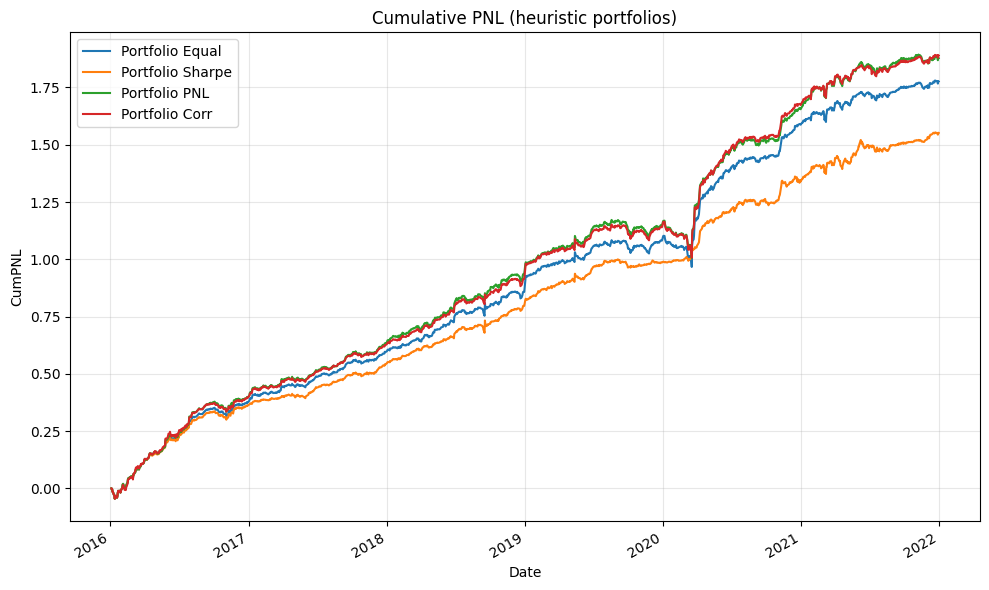

In [20]:
df = pd.DataFrame({
    'Portfolio Equal': portf_equal.cumpnl,
    'Portfolio Sharpe': portf_sharpe.cumpnl,
    'Portfolio PNL': portf_pnl.cumpnl,
    'Portfolio Corr': portf_corr.cumpnl
})

df.plot(figsize=(10, 6), title='Cumulative PNL (heuristic portfolios)')
plt.xlabel('Date')
plt.ylabel('CumPNL')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Portfolio Equal

In [22]:
stats_equal.print_average_stats()

****************************************
average_turnover = 0.6164155368758698
average_Sharpe = 3.425813095911765
sum_pnl = 1.7762045123543422
****************************************


In [28]:
stats_pnl.corr_with(portf_sharpe)

np.float64(0.7638689130543891)

#### Portfolio Sharpe

In [23]:
stats_sharpe.print_average_stats()

****************************************
average_turnover = 0.6647693004594282
average_Sharpe = 3.6987018389529855
sum_pnl = 1.5517934988848325
****************************************


#### Portfolio PNL

In [24]:
stats_pnl.print_average_stats()

****************************************
average_turnover = 0.592550779031232
average_Sharpe = 3.3286109710696383
sum_pnl = 1.8780934341013547
****************************************


#### Portfolio Correlations

In [25]:
stats_corr.print_average_stats()

****************************************
average_turnover = 0.6102049210616908
average_Sharpe = 3.409041729701474
sum_pnl = 1.88909679689289
****************************************
